# Visual Inspection of Real vs GAN-Generated Images

This notebook qualitatively compares real dermoscopic images with GAN-generated samples.

Objectives:
1. Visually assess anatomical plausibility
2. Identify potential artifacts
3. Compare color distribution and lesion structure
4. Provide qualitative evidence supporting GAN-based augmentation

This analysis supports the discussion section of the manuscript.

In [15]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

import sys
sys.path.insert(0, "..")
from configs.config import CLASSES

class_names = CLASSES
REAL_DIR = "../dataset/processed/train"
GAN_DIR = "../dataset/synthetic"

In [16]:
def load_random_images(folder, n=5):
    images = []
    files = os.listdir(folder)
    files = [f for f in files if f.lower().endswith((".jpg", ".png"))]
    
    selected = random.sample(files, min(n, len(files)))
    
    for file in selected:
        img = Image.open(os.path.join(folder, file)).convert("RGB")
        images.append(img)
    
    return images

In [17]:
def compare_real_vs_gan(class_name, n=5):
    
    real_folder = os.path.join(REAL_DIR, class_name)
    gan_folder = os.path.join(GAN_DIR, class_name)
    
    real_images = load_random_images(real_folder, n)
    gan_images = load_random_images(gan_folder, n)
    
    plt.figure(figsize=(12, 5))
    
    for i in range(n):
        # Real
        plt.subplot(2, n, i+1)
        plt.imshow(real_images[i])
        plt.axis("off")
        if i == 0:
            plt.title("Real")
        
        # GAN
        plt.subplot(2, n, n+i+1)
        plt.imshow(gan_images[i])
        plt.axis("off")
        if i == 0:
            plt.title("GAN")
    
    plt.suptitle(f"Real vs GAN Samples — Class: {class_name}")
    plt.show()

In [18]:
import pandas as pd

metadata = pd.read_csv("../data/HAM10000/metadata.csv")

metadata = metadata[["image_id", "dx"]]

metadata.head()

,image_id,dx
0,ISIC_0027419,bkl
1,ISIC_0025030,bkl
2,ISIC_0026769,bkl
3,ISIC_0025661,bkl
4,ISIC_0031633,bkl


In [19]:

TRAIN_DIR = "../dataset/processed/train"

# Lấy danh sách ảnh train
train_images = os.listdir(TRAIN_DIR)

# Tạo DataFrame train với label
train_df = pd.DataFrame({
    "image_file": train_images
})

# Remove extension để match image_id
train_df["image_id"] = train_df["image_file"].str.replace(".jpg", "", regex=False)

# Merge với metadata
train_df = train_df.merge(metadata, on="image_id", how="left")

train_df.head()

,image_file,image_id,dx
0,ISIC_0024307.jpg,ISIC_0024307,nv
1,ISIC_0024308.jpg,ISIC_0024308,nv
2,ISIC_0024309.jpg,ISIC_0024309,nv
3,ISIC_0024311.jpg,ISIC_0024311,nv
4,ISIC_0024312.jpg,ISIC_0024312,bkl


In [20]:

GAN_DIR = "../dataset/synthetic"


def compare_real_vs_gan(class_name, n=5):
    
    # Lọc ảnh real theo label
    real_subset = train_df[train_df["dx"] == class_name]
    
    selected_real = real_subset.sample(n=min(n, len(real_subset)))
    
    real_images = []
    for file in selected_real["image_file"]:
        img = Image.open(os.path.join(TRAIN_DIR, file)).convert("RGB")
        real_images.append(img)
    
    # GAN images
    gan_folder = os.path.join(GAN_DIR, class_name)
    gan_files = os.listdir(gan_folder)
    gan_files = [f for f in gan_files if f.lower().endswith((".jpg", ".png"))]
    
    selected_gan = random.sample(gan_files, min(n, len(gan_files)))
    
    gan_images = []
    for file in selected_gan:
        img = Image.open(os.path.join(gan_folder, file)).convert("RGB")
        gan_images.append(img)
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(real_images[i])
        plt.axis("off")
        if i == 0:
            plt.title("Real")
        
        plt.subplot(2, n, n+i+1)
        plt.imshow(gan_images[i])
        plt.axis("off")
        if i == 0:
            plt.title("GAN")
    
    plt.suptitle(f"Real vs GAN — Class: {class_name}")
    plt.show()

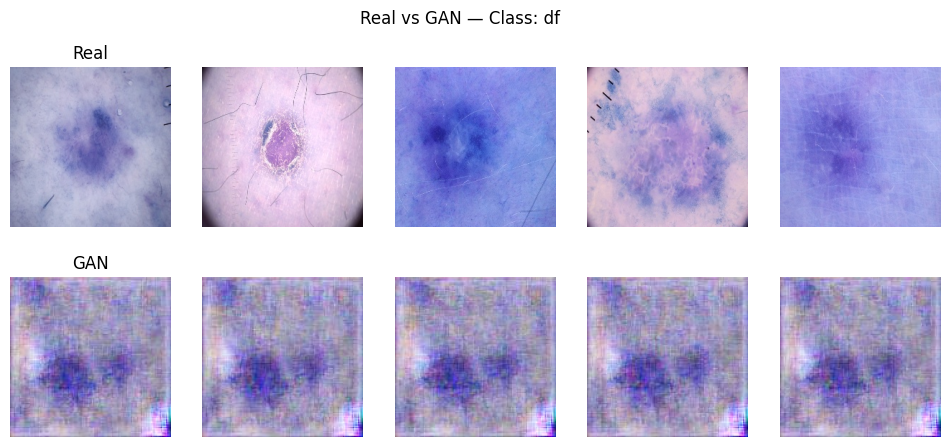

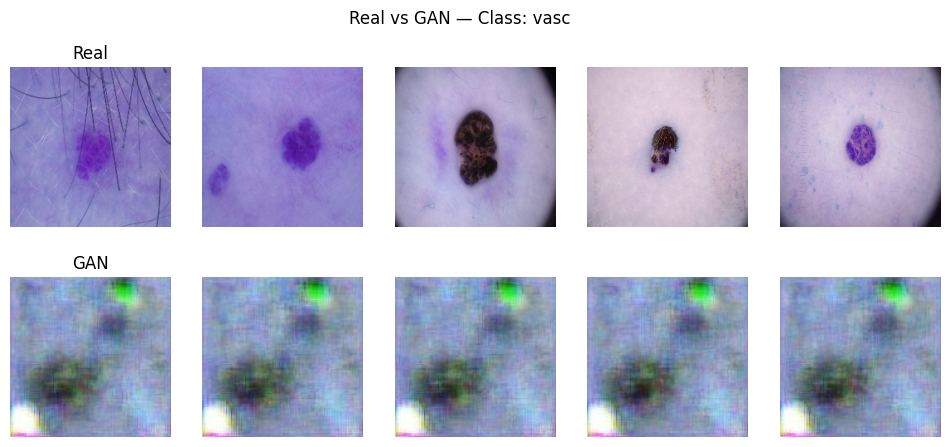

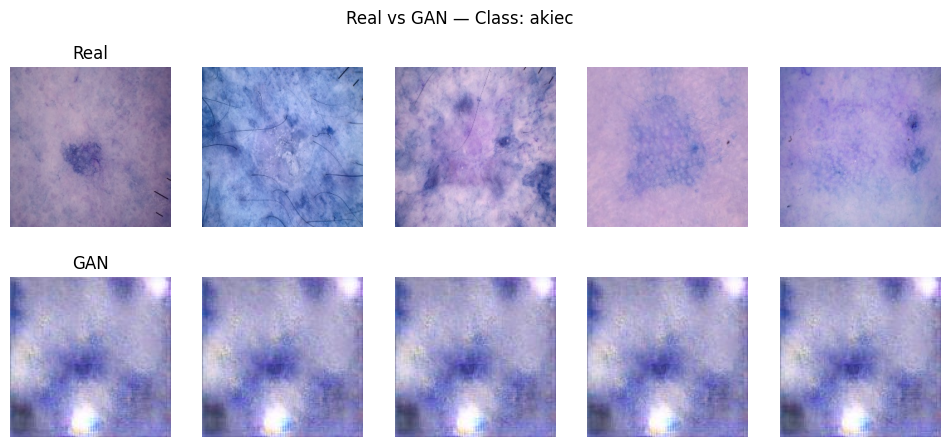

In [21]:
compare_real_vs_gan("df", n=5)
compare_real_vs_gan("vasc", n=5)
compare_real_vs_gan("akiec", n=5)

In [27]:
def pixel_distribution_comparison(class_name, n=20):
    
    real_subset = train_df[train_df["dx"] == class_name]
    selected_real = real_subset.sample(n=min(n, len(real_subset)))
    
    real_pixels = []
    gan_pixels = []

    for file in selected_real["image_file"]:
        img_path = os.path.join(TRAIN_DIR, file)
        img = Image.open(img_path).convert("RGB")
        real_pixels.extend(np.array(img).flatten())

    gan_folder = os.path.join(GAN_DIR, class_name)
    gan_files = [f for f in os.listdir(gan_folder) if f.lower().endswith((".jpg", ".png"))]
    selected_gan = random.sample(gan_files, min(n, len(gan_files)))
    
    for file in selected_gan:
        img = Image.open(os.path.join(gan_folder, file)).convert("RGB")
        gan_pixels.extend(np.array(img).flatten())

    plt.figure(figsize=(6,4))
    plt.hist(real_pixels, bins=50, alpha=0.5, label="Real", density=True)
    plt.hist(gan_pixels, bins=50, alpha=0.5, label="GAN", density=True)
    plt.title(f"Pixel Distribution — {class_name}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

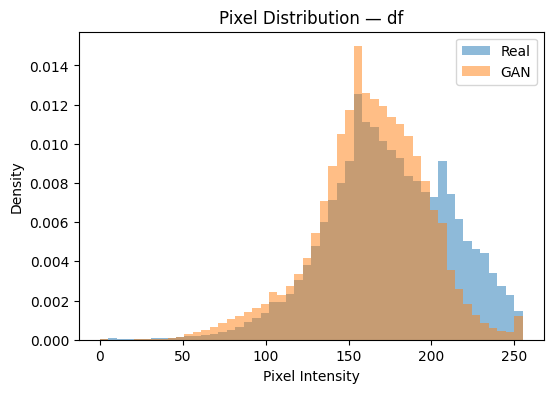

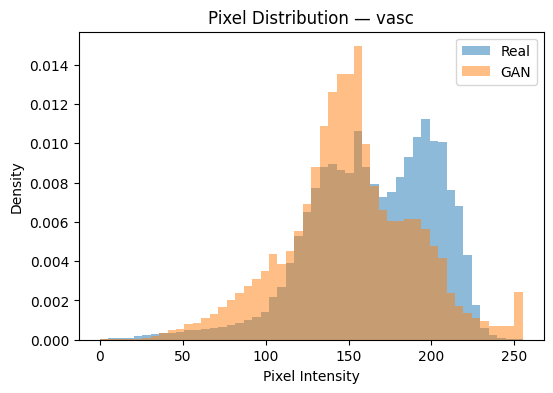

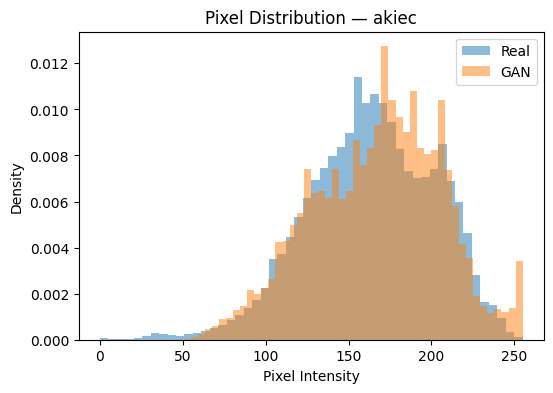

In [28]:
pixel_distribution_comparison("df")
pixel_distribution_comparison("vasc")
pixel_distribution_comparison("akiec")

## Observations

- GAN-generated samples preserve overall lesion shape and pigmentation structure.
- Minor texture smoothing is observed in some synthetic images.
- No obvious checkerboard artifacts or severe structural distortions were detected.
- Color distribution between real and synthetic samples appears comparable.

These qualitative findings suggest that the GAN model generates visually plausible dermoscopic images suitable for data augmentation.
